1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

2. Load the dataset

In [2]:
df = pd.read_csv("Blood Donation_questions_and_answers.csv")

3. Basic structure check

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nGeneral info:")
print(df.info())

Shape of dataset: (3429, 2)

Columns:
Index(['Question', 'Answer'], dtype='str')

First 5 rows:
                                            Question  \
0  Question 1: How do blood donation centers ensu...   
1  Question 2: What role can social media influen...   
2  Question 3: How can blood donation centers lev...   
3  Question 4: What measures can blood donation c...   
4  Question 5: How do blood donation centers enga...   

                                              Answer  
0  Blood donation centers utilize temperature-con...  
1  Social media influencers and digital advocates...  
2  Blood donation centers can collaborate with co...  
3  Blood donation centers can provide multilingua...  
4  Blood donation centers collaborate with health...  

Data types:
Question    str
Answer      str
dtype: object

General info:
<class 'pandas.DataFrame'>
RangeIndex: 3429 entries, 0 to 3428
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  

4. Check for missing values

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("Empty strings in each column:")
for col in df.columns:
    print(col, (df[col].astype(str).str.strip() == "").sum())

Missing values per column:
Question    0
Answer      0
dtype: int64
Empty strings in each column:
Question 0
Answer 0


5. Check for duplicates

In [5]:
print("Number of fully duplicated rows:", df.duplicated().sum())

print("Number of duplicated answers:", df["Answer"].duplicated().sum())

duplicate_questions = df[df["Question"].duplicated(keep=False)].sort_values("Question")
print(duplicate_questions.head(20))

print("Number of duplicated answers:", df["Answer"].duplicated().sum())

duplicate_questions = df[df["Question"].duplicated(keep=False)].sort_values("Question")
print(duplicate_questions.head(20))

Number of fully duplicated rows: 0
Number of duplicated answers: 13
                                               Question  \
317   How can health institutions reshape female hea...   
335   How can health institutions reshape female hea...   
626   How can individuals benefit from consuming mor...   
573   How can individuals benefit from consuming mor...   
625   How can individuals benefit from consuming mor...   
578   How can individuals benefit from consuming mor...   
564   How can individuals benefit from consuming mor...   
604   How can individuals benefit from increasing th...   
521   How can individuals benefit from increasing th...   
618   How can individuals benefit from increasing th...   
563   How can individuals benefit from increasing th...   
234   How can mobile donation units improve access t...   
283   How can mobile donation units improve access t...   
3139  How do blood donation centers ensure the safet...   
2041  How do blood donation centers ensure the 

6. Clean the question numbering

In [6]:
df["Question_clean"] = df["Question"].str.replace(r"^Question\s*\d+\s*:\s*", "", regex=True)

print(df[["Question", "Question_clean"]].head(10))

df["Question"] = df["Question_clean"]
df.drop(columns=["Question_clean"], inplace=True)

                                            Question  \
0  Question 1: How do blood donation centers ensu...   
1  Question 2: What role can social media influen...   
2  Question 3: How can blood donation centers lev...   
3  Question 4: What measures can blood donation c...   
4  Question 5: How do blood donation centers enga...   
5  Question 6: What initiatives can blood donatio...   
6  Question 7: How can blood donation centers har...   
7  Question 8: What strategies can blood donation...   
8  Question 9: How do blood donation centers coll...   
9  Question 10: What measures can blood donation ...   

                                      Question_clean  
0  How do blood donation centers ensure the safet...  
1  What role can social media influencers and dig...  
2  How can blood donation centers leverage corpor...  
3  What measures can blood donation centers imple...  
4  How do blood donation centers engage with loca...  
5  What initiatives can blood donation centers un... 

7. Normalize text spacing

In [7]:
df["Question"] = df["Question"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
df["Answer"] = df["Answer"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

8. Create text length features

In [8]:
df["question_char_count"] = df["Question"].apply(len)
df["answer_char_count"] = df["Answer"].apply(len)

df["question_word_count"] = df["Question"].apply(lambda x: len(str(x).split()))
df["answer_word_count"] = df["Answer"].apply(lambda x: len(str(x).split()))

print(df[["question_char_count", "answer_char_count", "question_word_count", "answer_word_count"]].describe())

       question_char_count  answer_char_count  question_word_count  \
count          3429.000000        3429.000000          3429.000000   
mean            140.492563         312.123068            19.581511   
std              56.090008         123.714001             7.386845   
min              33.000000          83.000000             6.000000   
25%             100.000000         230.000000            14.000000   
50%             132.000000         286.000000            19.000000   
75%             168.000000         362.000000            23.000000   
max             435.000000        1068.000000            54.000000   

       answer_word_count  
count        3429.000000  
mean           40.704579  
std            15.926883  
min             9.000000  
25%            30.000000  
50%            37.000000  
75%            47.000000  
max           139.000000  


9. Visualize question and answer lengths

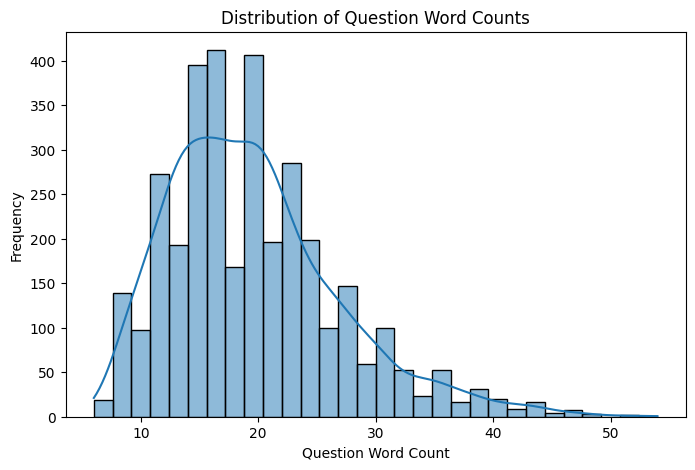

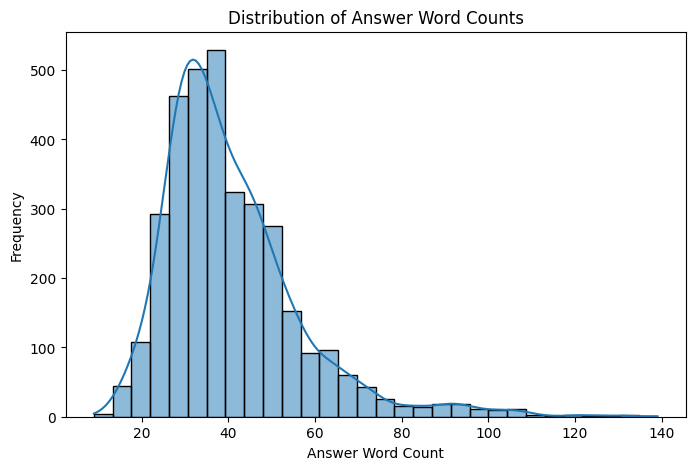

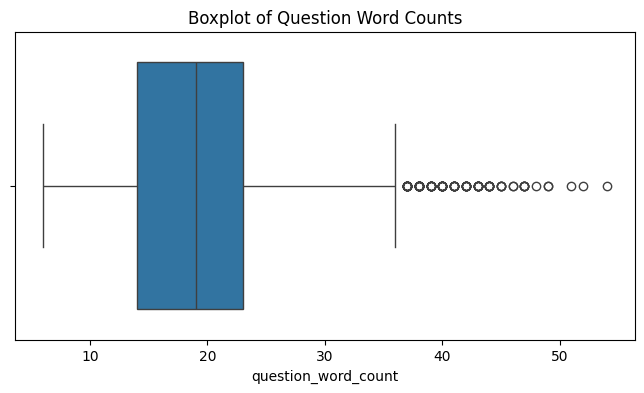

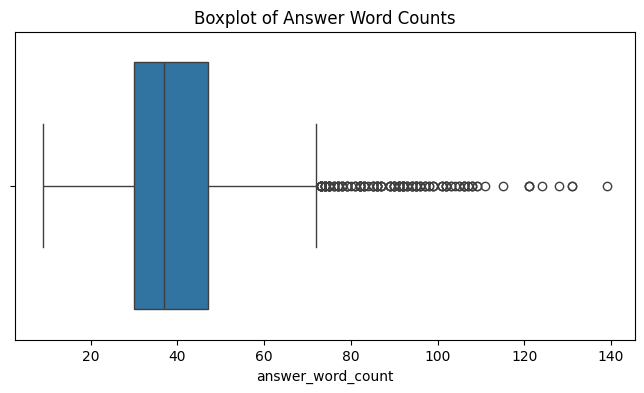

In [9]:
#Histogram for question word counts
plt.figure(figsize=(8,5))
sns.histplot(df["question_word_count"], bins=30, kde=True)
plt.title("Distribution of Question Word Counts")
plt.xlabel("Question Word Count")
plt.ylabel("Frequency")
plt.show()

#Histogram for answer word counts
plt.figure(figsize=(8,5))
sns.histplot(df["answer_word_count"], bins=30, kde=True)
plt.title("Distribution of Answer Word Counts")
plt.xlabel("Answer Word Count")
plt.ylabel("Frequency")
plt.show()

# Boxplots to detect unusually short or long entries
plt.figure(figsize=(8,4))
sns.boxplot(x=df["question_word_count"])
plt.title("Boxplot of Question Word Counts")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["answer_word_count"])
plt.title("Boxplot of Answer Word Counts")
plt.show()

10. Identify very short or suspiciously long questions/answers

In [10]:
# Very short questions
short_questions = df[df["question_word_count"] < 4]
print("Very short questions:", len(short_questions))
print(short_questions[["Question", "Answer"]].head(20))

# Very short answers
short_answers = df[df["answer_word_count"] < 5]
print("Very short answers:", len(short_answers))
print(short_answers[["Question", "Answer"]].head(20))

Very short questions: 0
Empty DataFrame
Columns: [Question, Answer]
Index: []
Very short answers: 0
Empty DataFrame
Columns: [Question, Answer]
Index: []


11. Check punctuation and formatting issues

In [11]:
#Questions not ending with question mark

no_question_mark = df[~df["Question"].str.endswith("?")]
print("Questions not ending with '?':", len(no_question_mark))
print(no_question_mark[["Question"]].head(20))

# Answers ending with question mark by mistake

answer_ends_with_qmark = df[df["Answer"].str.endswith("?")]
print("Answers ending with '?':", len(answer_ends_with_qmark))
print(answer_ends_with_qmark[["Question", "Answer"]].head(20))

Questions not ending with '?': 2
                                               Question
122   How do blood donation centers leverage social ...
1767  How do organizers of blood drives coordinate w...
Answers ending with '?': 1
                                              Question  \
573  How can individuals benefit from consuming mor...   

                                                Answer  
573  Mushrooms provide essential nutrients and anti...  


12. Check basic text uniqueness

In [12]:
print("Unique questions:", df["Question"].nunique())
print("Unique answers:", df["Answer"].nunique())

# Uniqueness ratio:

print("Question uniqueness ratio:", df["Question"].nunique() / len(df))
print("Answer uniqueness ratio:", df["Answer"].nunique() / len(df))

Unique questions: 3376
Unique answers: 3416
Question uniqueness ratio: 0.9845435987168271
Answer uniqueness ratio: 0.9962088072324293


13. Detect repeated answer patterns

Answer
Blood drive hosts can employ strategies such as gamified donation challenges, virtual blood drives, or partnerships with gaming influencers to engage with potential donors through online gaming communities, esports events, or virtual reality platforms, leveraging digital technologies and gaming culture to promote blood donation as a positive social activity, build community, and encourage participation among tech-savvy audiences who are passionate about making a difference in the world through digital activism and social impact initiatives.                                                                                                                                    2
Blood donor recognition programs, appreciation events, or donor loyalty rewards play a significant role in fostering donor retention, building a sense of belonging, and cultivating a dedicated community of blood donors committed to saving lives through regular donation by acknowledging donors' contributions, exp

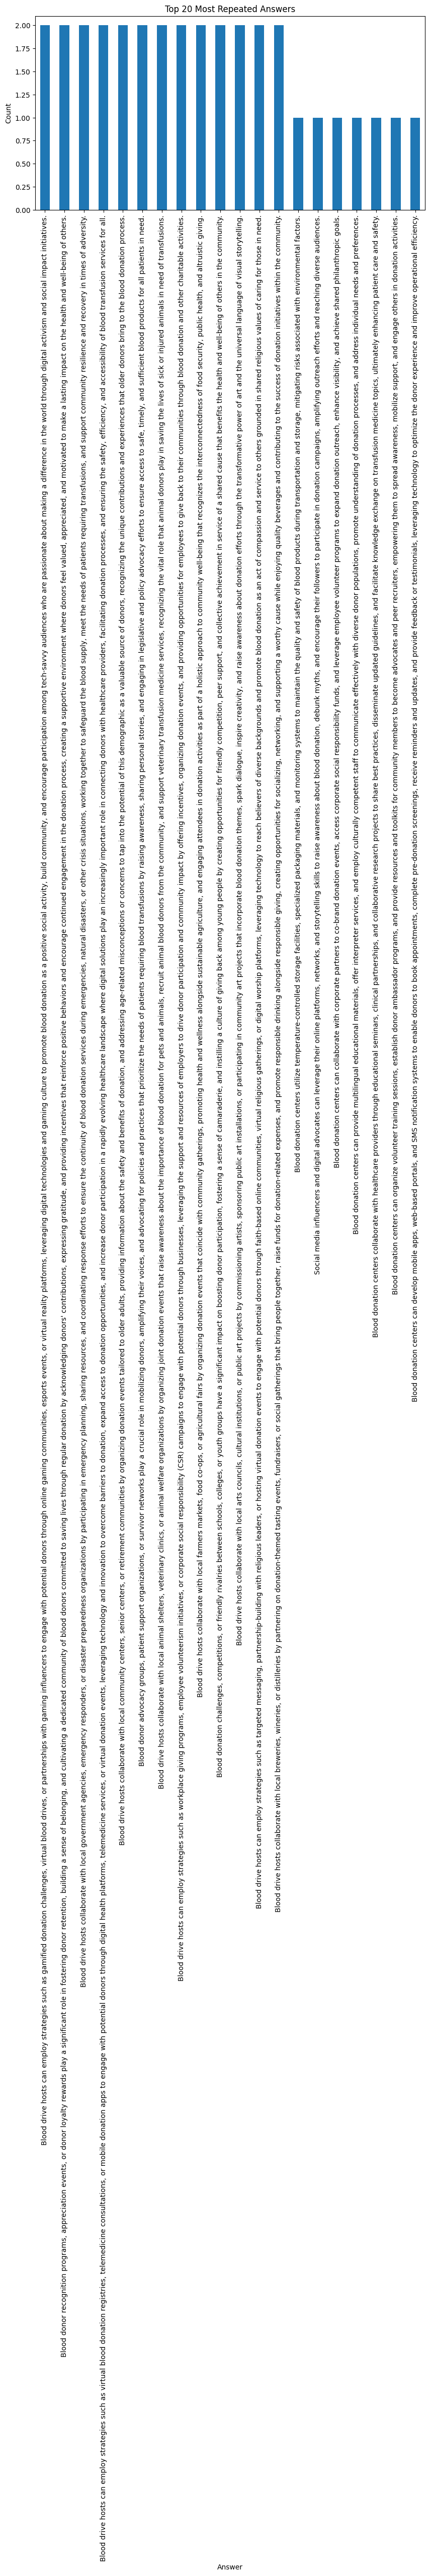

In [13]:
top_repeated_answers = df["Answer"].value_counts().head(20)
print(top_repeated_answers)

# Visualization

plt.figure(figsize=(10,5))
top_repeated_answers.plot(kind="bar")
plt.title("Top 20 Most Repeated Answers")
plt.ylabel("Count")
plt.show()

14. Detect repeated question patterns

In [14]:
top_repeated_questions = df["Question"].value_counts().head(20)
print(top_repeated_questions)

Question
How do donor deferral policies balance the need to protect blood supply safety with principles of donor inclusivity, non-discrimination, and respect for donor autonomy and rights?                                                                                                                                                                                         4
How can individuals benefit from consuming more whole grains for donation?                                                                                                                                                                                                                                                                                                  3
How do appointment scheduling systems adapt to unforeseen events or emergencies that may impact donation center operations?                                                                                                                                        

15. Examine frequent words in questions

[('centers', 789), ('role', 561), ('play', 513), ('strategies', 461), ('organizations', 447), ('programs', 404), ('health', 373), ('ensure', 339), ('collaborate', 339), ('community', 329), ('address', 317), ('appointment', 296), ('individuals', 290), ('transfusion', 266), ('among', 264), ('engage', 263), ('awareness', 253), ('impact', 251), ('promote', 247), ('about', 243), ('their', 235), ('from', 233), ('support', 222), ('such', 222), ('services', 215), ('recruitment', 213), ('during', 206), ('efforts', 203), ('public', 199), ('participation', 197)]


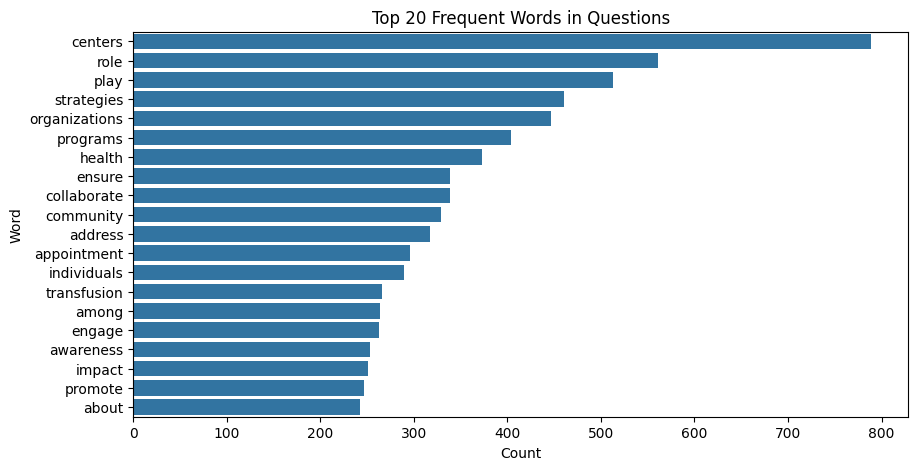

In [15]:
question_text = " ".join(df["Question"].astype(str).str.lower())
words = re.findall(r"\b[a-zA-Z]+\b", question_text)

stopwords = {
    "the", "is", "are", "a", "an", "and", "or", "to", "of", "in", "for", "on",
    "how", "what", "can", "do", "does", "if", "with", "by", "blood", "donation",
    "donor", "donors"
}

filtered_words = [word for word in words if word not in stopwords and len(word) > 2]
word_counts = Counter(filtered_words)

print(word_counts.most_common(30))

# Visualization of most common words in questions

top_words = pd.DataFrame(word_counts.most_common(20), columns=["Word", "Count"])

plt.figure(figsize=(10,5))
sns.barplot(data=top_words, x="Count", y="Word")
plt.title("Top 20 Frequent Words in Questions")
plt.show()

16. Examine frequent words in answers

In [16]:
answer_text = " ".join(df["Answer"].astype(str).str.lower())
answer_words = re.findall(r"\b[a-zA-Z]+\b", answer_text)

filtered_answer_words = [word for word in answer_words if word not in stopwords and len(word) > 2]
answer_word_counts = Counter(filtered_answer_words)

print(answer_word_counts.most_common(30))

[('centers', 1020), ('community', 898), ('providing', 826), ('health', 732), ('their', 713), ('support', 700), ('programs', 615), ('about', 607), ('organizations', 598), ('such', 556), ('may', 520), ('events', 517), ('that', 494), ('awareness', 490), ('offering', 486), ('efforts', 480), ('strategies', 474), ('campaigns', 472), ('participation', 449), ('include', 449), ('outreach', 438), ('appointment', 427), ('ensure', 426), ('initiatives', 414), ('services', 413), ('healthcare', 413), ('opportunities', 409), ('safety', 406), ('social', 402), ('engagement', 399)]


17. Manual topic tagging by keyword

Topic
Other                    1675
Access/Logistics          943
Awareness/Recruitment     465
Safety/Screening          207
Eligibility                58
Health/Nutrition           49
Fear/Emotions              32
Name: count, dtype: int64


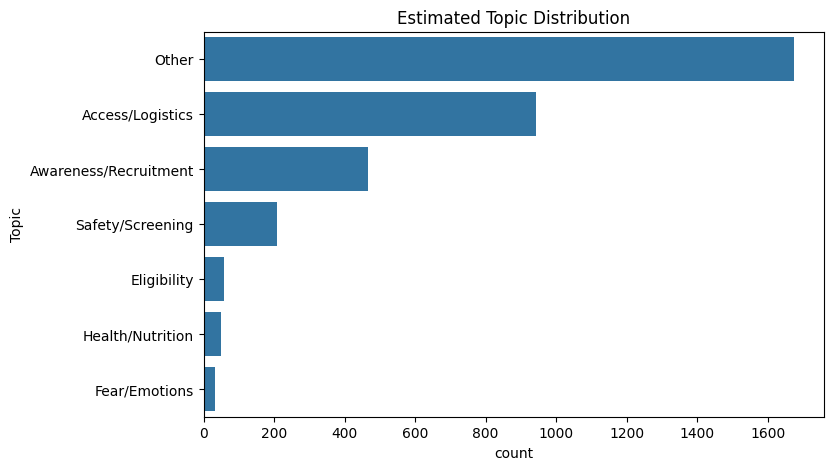

In [17]:
def assign_topic(question):
    q = question.lower()
    if any(word in q for word in ["eligibility", "eligible", "can i donate", "allowed"]):
        return "Eligibility"
    elif any(word in q for word in ["iron", "hemoglobin", "diet", "nutrition", "vitamin"]):
        return "Health/Nutrition"
    elif any(word in q for word in ["fear", "anxiety", "pain", "nervous"]):
        return "Fear/Emotions"
    elif any(word in q for word in ["mobile", "remote", "access", "location", "center"]):
        return "Access/Logistics"
    elif any(word in q for word in ["campaign", "awareness", "social media", "community"]):
        return "Awareness/Recruitment"
    elif any(word in q for word in ["safety", "safe", "infection", "quality", "screening"]):
        return "Safety/Screening"
    else:
        return "Other"
    
    
# Applicvation of topic

df["Topic"] = df["Question"].apply(assign_topic)
print(df["Topic"].value_counts())

# Visualization of topic distribution

plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Topic", order=df["Topic"].value_counts().index)
plt.title("Estimated Topic Distribution")
plt.show()


18. Check question-answer alignment manually

In [18]:
sample_review = df.sample(30, random_state=42)[["Question", "Answer"]]
print(sample_review)

# Save for documentation review:

sample_review.to_csv("sample_review_for_alignment.csv", index=False)

                                               Question  \
578   How can individuals benefit from consuming mor...   
1055  In what ways can blood transfusion approaches ...   
564   How can individuals benefit from consuming mor...   
2298  How can partnerships with educational institut...   
3243  What strategies can blood donation centers use...   
2225  Question 44 What impact does donor education a...   
3396  How do blood donation centers collaborate with...   
298   What role do partnerships with local organizat...   
443   What is the role of research in advancing auto...   
976   How do blood donation programs engage with hea...   
985   What strategies are employed to promote blood ...   
1376  How can blood donation centers leverage donor ...   
3048  How do blood donation organizations leverage s...   
1656  What strategies can be employed to increase do...   
2979  How do blood drive hosts collaborate with loca...   
506   How can a balanced diet help individuals prepa... 

19. Check whether one question has multiple different answers

In [19]:
question_answer_counts = df.groupby("Question")["Answer"].nunique().reset_index()
multiple_answers = question_answer_counts[question_answer_counts["Answer"] > 1]

print("Questions with more than one unique answer:", len(multiple_answers))
print(multiple_answers.head(20))

# Merge back to inspect:

conflicting_qas = df[df["Question"].isin(multiple_answers["Question"])]
print(conflicting_qas.sort_values("Question").head(50))

Questions with more than one unique answer: 36
                                               Question  Answer
542   How can blood supply and demand be effectively...       2
669   How can health institutions reshape female hea...       2
742   How can individuals benefit from consuming mor...       2
763   How can individuals benefit from consuming mor...       3
773   How can individuals benefit from increasing th...       2
785   How can individuals benefit from increasing th...       2
832   How can mobile donation units improve access t...       2
856   How can public perceptions of vaccine-incentiv...       2
945   How do appointment scheduling systems adapt to...       3
1132  How do blood donation centers ensure the ethic...       2
1159  How do blood donation centers ensure the safet...       2
1259  How do blood donation facilitation programs en...       2
1335  How do blood donation organizations collaborat...       2
1394  How do blood donation programs engage with fai...  

20. Save a cleaned EDA-ready version of the dataset

In [20]:
df.to_csv("blood_donation_qa_cleaned.csv", index=False)

21. Create an EDA summary table

In [21]:
eda_summary = {
    "Total rows": len(df),
    "Total columns": df.shape[1],
    "Unique questions": df["Question"].nunique(),
    "Unique answers": df["Answer"].nunique(),
    "Fully duplicated rows": df.duplicated().sum(),
    "Duplicated questions": df["Question"].duplicated().sum(),
    "Duplicated answers": df["Answer"].duplicated().sum(),
    "Average question words": round(df["question_word_count"].mean(), 2),
    "Average answer words": round(df["answer_word_count"].mean(), 2),
    "Min question words": df["question_word_count"].min(),
    "Max question words": df["question_word_count"].max(),
    "Min answer words": df["answer_word_count"].min(),
    "Max answer words": df["answer_word_count"].max()
}

summary_df = pd.DataFrame(list(eda_summary.items()), columns=["Metric", "Value"])
print(summary_df)


# Save summary to CSV

summary_df.to_csv("eda_summary.csv", index=False)

                    Metric    Value
0               Total rows  3429.00
1            Total columns     7.00
2         Unique questions  3376.00
3           Unique answers  3416.00
4    Fully duplicated rows    13.00
5     Duplicated questions    53.00
6       Duplicated answers    13.00
7   Average question words    19.58
8     Average answer words    40.70
9       Min question words     6.00
10      Max question words    54.00
11        Min answer words     9.00
12        Max answer words   139.00
